In [1]:
#!/usr/bin/env python3 

In [31]:
# Importing the necessary modules 
import os 
import cv2 
import joblib 
import numpy as np 
import tensorflow as tf 
import matplotlib.pyplot as plt 
from tensorflow.keras import layers, models 

In [32]:
# Setting the configurations 
imageSize = (128, 128)
batchSize = 32 
dataDir = "dataset" 

In [33]:
# Load and split the dataset 
trainDs = tf.keras.utils.image_dataset_from_directory(
    dataDir, 
    validation_split=0.2, 
    subset="training", 
    seed=123, 
    image_size=imageSize, 
    batch_size=batchSize, 
    color_mode="grayscale" 
)

Found 53 files belonging to 5 classes.
Using 43 files for training.


In [34]:
# Getting the validation data
validationDs = tf.keras.utils.image_dataset_from_directory(
    dataDir,
    validation_split=0.2, 
    subset="validation", 
    seed=123, 
    image_size=imageSize, 
    batch_size=batchSize, 
    color_mode="grayscale"
)

Found 53 files belonging to 5 classes.
Using 10 files for validation.


In [35]:
# Getting the class names 
classNames = trainDs.class_names
print(f"Classes found: {classNames}")

Classes found: ['adams', 'kim', 'mike', 'sarah', 'unknown']


In [36]:
# Performance optimization 
AUTOTUNE = tf.data.AUTOTUNE
trainDs = trainDs.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) 
validationDs = validationDs.cache().prefetch(buffer_size=AUTOTUNE) 

In [37]:
# Getting the number of classes 
numClasses = len(classNames) 

# Building the neural network 
model = models.Sequential([
    # Rescaling pixel values from [0, 255] to [0, 1] 
    layers.Rescaling(1./255, input_shape=(128, 128, 1)), 

    # Feature extraction (CNN Layers) 
    layers.Conv2D(32, 3, activation="relu"), 
    layers.MaxPooling2D(), 
    layers.Conv2D(64, 3, activation="relu"), 
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), 
    layers.MaxPooling2D(), 

    # Classification (Dense Layers) 
    layers.Flatten(), 
    layers.Dense(128, activation="relu"), 
    layers.Dropout(0.5), 
    layers.Dense(numClasses, activation="softmax") 
])

# Compile the model
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

# Model summary 
model.summary() 

/Users/mbonuchinedum/anaconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,709 (12.61 MB)

 Trainable params: 3,304,709 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Training the model 
epochs = 32

# Training the model 
history = model.fit(trainDs, validation_data=validationDs, epochs=epochs) 

Epoch 1/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.1395 - loss: 1.7536 - val_accuracy: 0.2000 - val_loss: 1.6288
Epoch 2/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.1395 - loss: 1.6849 - val_accuracy: 0.5000 - val_loss: 1.5783
Epoch 3/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3023 - loss: 1.5580 - val_accuracy: 0.2000 - val_loss: 1.5850
Epoch 4/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.2791 - loss: 1.5445 - val_accuracy: 0.2000 - val_loss: 1.5785
Epoch 5/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2791 - loss: 1.4931 - val_accuracy: 0.4000 - val_loss: 1.5012
Epoch 6/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5581 - loss: 1.3905 - val_accuracy: 0.5000 - val_loss: 1.4295
Epoch 7/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5116 - loss: 1.3423 - val_accuracy: 0.6000 - val_loss: 1.3686
Epoch 8/32
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5349 - loss: 1.2457 - val_accuracy: 0.5000 - val_loss: 1

In [39]:
# Bundlie weights + metadata 
modelMetadata = {
    "model": model, 
    "weights": model.get_weights(), 
    "classNames": classNames, 
    "imageSize": imageSize
}

# Saving the model 
joblib.dump(modelMetadata, "model.joblib")
print("Model bundle saved successfully!") 

Model bundle saved successfully!


<h2 style="border-radius: 7px; background-color: blue; color: white; width: 45%; padding: 10px; padding-left: 20px; padding-right: 20px;"> Performing Inference Using Joblib </h2>
<p> To use the model in a <span style="background-color: blue; color:white; padding: 5px"> new script or app </span>, here is how you load the bundle and predict </p>

In [40]:
# Importing the necessary modules 
import numpy as np 
import joblib 
import tensorflow as tf 

# loading the bundle 
bundle = joblib.load("model.joblib")

In [41]:
# Reconstruct the model 
def loadAndPredict(imagePath): 
    # Load the model 
    model = bundle["model"]

    # Load the weights 
    model.set_weights(bundle["weights"]) 

    # Preprocess image 
    image = tf.keras.utils.load_img(imagePath, color_mode="grayscale", target_size=bundle["imageSize"]) 
    imageArray = tf.keras.utils.img_to_array(image) 
    imageArray = tf.expand_dims(imageArray, 0) 

    # Predict the class 
    predictions = model.predict(imageArray) 
    score = tf.nn.softmax(predictions[0])

    # Getting the result 
    result = bundle["classNames"][np.argmax(score)] 
    confidence = 100 * np.max(score) 

    # Return the result 
    return f"This fingerprint likely belongs to {result} ({confidence:.2f}% confidence)" 

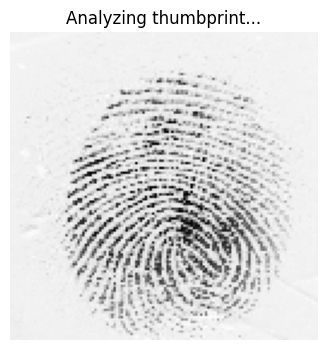

In [48]:
# Getting the image 
imageTest = "dataset/sarah/4_2_right_real_ZK9500.jpg"

# Load the image 
image = tf.keras.utils.load_img(
    imageTest, 
    color_mode="grayscale", 
    target_size=(128, 128)
)

# Display the thumbprint 
plt.figure(figsize=(4, 4)) 
plt.imshow(image, cmap="gray")
plt.title("Analyzing thumbprint...") 
plt.axis("off") 
plt.show() 

In [49]:
# Performing inference 
loadAndPredict(imageTest) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


'This fingerprint likely belongs to sarah (39.92% confidence)'